# Data Overview

Cache layout: `data/raw/{source}/{zone}/{datatype}.parquet`. Source priority: energinet > entsoe (energinet is authoritative for DK zones, higher resolution, longer history).

In [1]:
from pathlib import Path
import pandas as pd

from da_forecast.sources.cache import ParquetCache
from da_forecast.config import ZONES, RAW_DIR

In [2]:
cache = ParquetCache(RAW_DIR)
sources = ["energinet", "entsoe"]

rows = []
for source in sources:
    source_dir = RAW_DIR / source
    if not source_dir.exists():
        continue
    for zone_dir in sorted(source_dir.iterdir()):
        if not zone_dir.is_dir():
            continue
        zone = zone_dir.name
        for pq in sorted(zone_dir.glob("*.parquet")):
            datatype = pq.stem
            df = cache.load(source, zone, datatype)
            if df is not None and not df.empty:
                rows.append({
                    "source": source,
                    "zone": zone,
                    "datatype": datatype,
                    "rows": len(df),
                    "start": str(df.index.min()),
                    "end": str(df.index.max()),
                })

availability = pd.DataFrame(rows)
availability

,source,zone,datatype,rows,start,end
0,energinet,DK_1,day_ahead_prices,8758,2024-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00
1,energinet,DK_1,load_forecast,8746,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
2,energinet,DK_1,production_exchange,8756,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
3,energinet,DK_1,wind_solar_forecast,8738,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
4,energinet,DK_2,day_ahead_prices,8758,2024-10-01 00:00:00+00:00,2025-09-30 21:00:00+00:00
5,energinet,DK_2,load_forecast,8746,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
6,energinet,DK_2,production_exchange,8756,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
7,energinet,DK_2,wind_solar_forecast,8738,2024-10-01 00:00:00+00:00,2025-09-30 23:00:00+00:00
8,entsoe,DE_LU,day_ahead_prices,5136,2025-03-01 00:00:00+01:00,2025-10-01 00:00:00+02:00
9,entsoe,DE_LU,load_forecast,20542,2025-03-01 00:00:00+01:00,2025-10-01 01:00:00+02:00


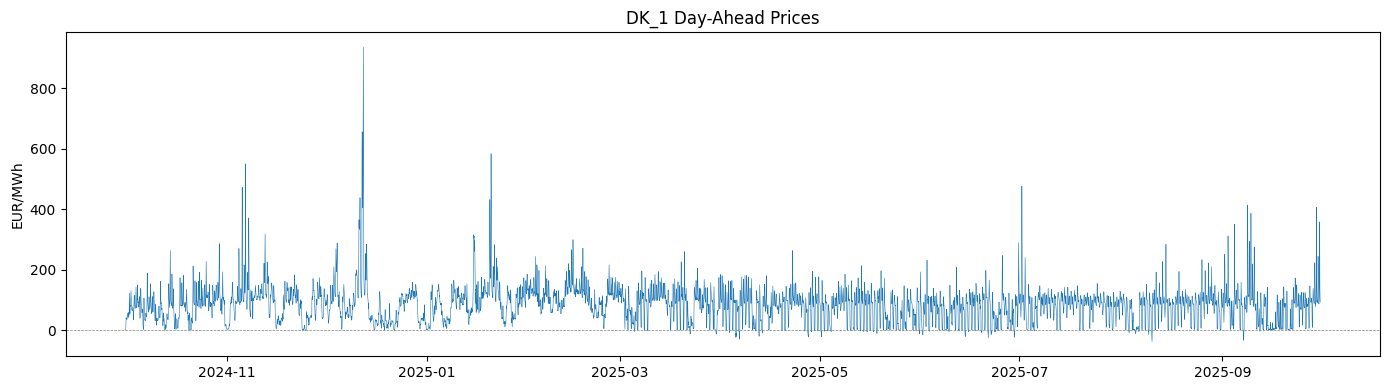

In [3]:
import matplotlib.pyplot as plt

prices = cache.load("energinet", "DK_1", "day_ahead_prices")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prices.index, prices["price_eur_mwh"], linewidth=0.4, color="#1f77b4")
ax.set_ylabel("EUR/MWh")
ax.set_title("DK_1 Day-Ahead Prices")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()